# Part 2: Time Series Modeling

In this notebook, you will implement functions to extract features from time series data and build ARIMA models.

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from pathlib import Path
import os

# Set style for plots
sns.set_theme(style="darkgrid")
%matplotlib inline

## 1. Feature Extraction

Implement the `extract_time_series_features` function to calculate rolling window features.

In [11]:
def extract_time_series_features(data, window_size=60):
    """Extract rolling features from physiological signals with speed optimization."""

    features = []

    for sid in data['subject_id'].unique():
        for sess in data[data['subject_id'] == sid]['session'].unique():
            df = data[(data['subject_id'] == sid) & (data['session'] == sess)].copy()
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.set_index('timestamp').sort_index()

            # Downsample to 2-second intervals to reduce size
            df_numeric = df.select_dtypes(include='number')
            df_resampled = df_numeric.resample('2s').mean().dropna()

# Add back subject/session info
            df_resampled['subject_id'] = sid
            df_resampled['session'] = sess
            df = df_resampled
            window_points = int(window_size / 2)  # 60s = 30 points at 2s interval

            for col in ['heart_rate', 'eda', 'temperature']:
                if col not in df.columns:
                    continue

                roll = df[col].rolling(window=window_points)

                # Compute mean, std, min, max in one call
                stats = roll.agg(['mean', 'std', 'min', 'max'])

                # Autocorrelation (custom, slower part)
                ac = roll.apply(lambda x: x.autocorr(lag=1) if len(x) >= 2 else np.nan, raw=False)

                feat = pd.DataFrame({
                    'subject_id': sid,
                    'session': sess,
                    'signal': col,
                    'time': stats.index,
                    f'{col}_mean': stats['mean'].values,
                    f'{col}_std': stats['std'].values,
                    f'{col}_min': stats['min'].values,
                    f'{col}_max': stats['max'].values,
                    f'{col}_autocorr': ac.values
                })

                features.append(feat)

    return pd.concat(features, ignore_index=True)

## 2. ARIMA Modeling

Implement the `build_arima_model` function to fit ARIMA models and generate diagnostic plots.

In [16]:
def build_arima_model(series, subject_id='S1', session='Final', signal_name='heart_rate', order=(1,1,1), output_dir='plots'):
    """Fit ARIMA model and save diagnostic plots."""
    
    os.makedirs(output_dir, exist_ok=True)

    # Fit model
    model = ARIMA(series, order=order)
    results = model.fit()

    # Compose base filename
    base_name = f"{subject_id}_{session}_{signal_name}"

    # Plot: Model fit
    plt.figure(figsize=(10, 4))
    plt.plot(series, label='Original')
    plt.plot(results.fittedvalues, label='Fitted')
    plt.title(f'{base_name} ARIMA Fit')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{base_name}_arima_fit.png'))
    plt.show()

    # Plot: Residuals
    plt.figure(figsize=(10, 4))
    plt.plot(results.resid)
    plt.title(f'{base_name} ARIMA Residuals')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'{base_name}_arima_residuals.png'))
    plt.show()

    return results

In [14]:
df_clean = pd.read_csv('data/processed/S1_processed.csv')
features_df = extract_time_series_features(df_clean, window_size=60)
features_df

,subject_id,session,signal,time,heart_rate_mean,heart_rate_std,heart_rate_min,heart_rate_max,heart_rate_autocorr,eda_mean,eda_std,eda_min,eda_max,eda_autocorr,temperature_mean,temperature_std,temperature_min,temperature_max,temperature_autocorr
0,S1,Midterm 1,heart_rate,2018-10-13 12:56:18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S1,Midterm 1,heart_rate,2018-10-13 12:56:20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S1,Midterm 1,heart_rate,2018-10-13 12:56:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S1,Midterm 1,heart_rate,2018-10-13 12:56:24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S1,Midterm 1,heart_rate,2018-10-13 12:56:26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6923035,S1,Final,temperature,2018-12-05 22:58:44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.290000,0.000000,30.29,30.2900,1.000000e+00
6923036,S1,Final,temperature,2018-12-05 22:58:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.290250,0.001369,30.29,30.2975,1.521839e-12
6923037,S1,Final,temperature,2018-12-05 22:58:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.290833,0.003432,30.29,30.3075,9.170121e-01
6923038,S1,Final,temperature,2018-12-05 22:58:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.291500,0.004895,30.29,30.3100,9.104640e-01


c:\Users\cbr98\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\cbr98\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\cbr98\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\cbr98\AppData\Local\Programs\Python\Python313\Lib

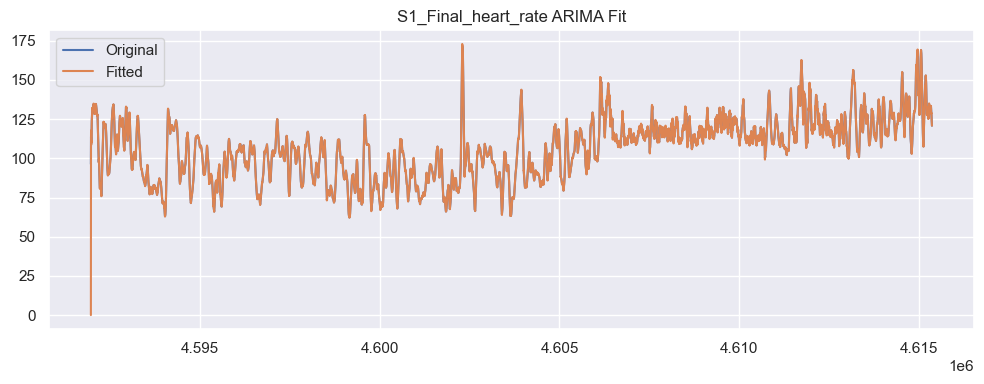

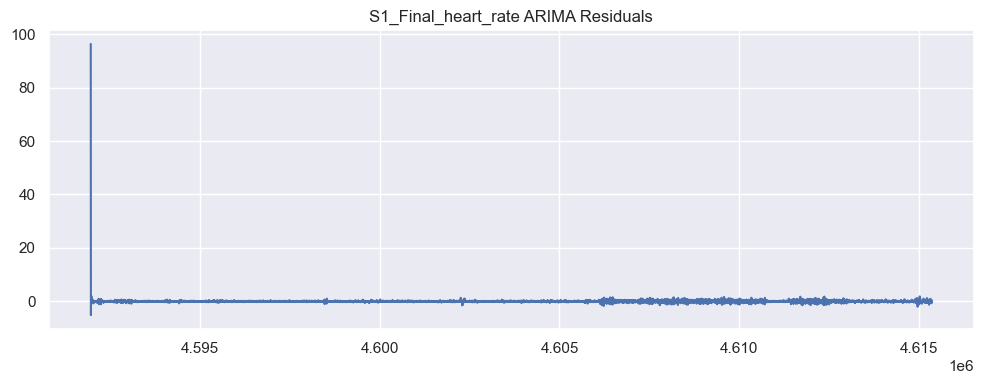

In [17]:
series = df_clean[df_clean['session'] == 'Final']['heart_rate'].dropna()
model = build_arima_model(series, subject_id='S1', session='Final', signal_name='heart_rate', order=(2,1,2))